# FIBO + Neo4j — Exploratory Data Analysis

Hands-on EDA of the FIBO ontology (T-Box) and the seeded counterparty/LEI graph (A-Box).

**Prereqs**: run the Cypher files in order before this notebook.

1. `cypher/00_setup.cypher`
2. `cypher/10_load_fibo.cypher`
3. `cypher/25_seed_abox.cypher`
4. `cypher/40_gds_analytics.cypher` (writes `systemicScore` and `communityId`)

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from dotenv import load_dotenv
from neo4j import GraphDatabase

sns.set_theme(style='whitegrid')
load_dotenv()
URI  = os.getenv('NEO4J_URI', 'neo4j://127.0.0.1:7687')
USER = os.getenv('NEO4J_USER', 'neo4j')
PWD  = os.getenv('NEO4J_PASSWORD', '12345678')
DB   = os.getenv('NEO4J_DATABASE', 'neo4j')
driver = GraphDatabase.driver(URI, auth=(USER, PWD))

def q(cypher, **params):
    with driver.session(database=DB) as s:
        return pd.DataFrame([r.data() for r in s.run(cypher, **params)])

q('RETURN 1 AS ok')

,ok
0,1


## 1. Inventory — labels & relationship types

## 1b. Load FIBO T-Box (if not already present)
If `:Class` nodes are absent, we import the FIBO ontology via **n10s** directly from the EDM Council CDN.

In [48]:

# Load FIBO ontology via n10s if :Class nodes are missing
if 'Class' not in labels['label'].values:
    print('Loading FIBO ontology modules via n10s...')
    fibo_urls = [
        'https://spec.edmcouncil.org/fibo/ontology/master/latest/FND/MetadataFND.rdf',
        'https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/MetadataBE.rdf',
        'https://spec.edmcouncil.org/fibo/ontology/master/latest/FBC/MetadataFBC.rdf',
        'https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/LegalEntities/LegalPersons.rdf',
        'https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/LegalEntities/LEIEntities.rdf',
        'https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/Corporations/Corporations.rdf',
        'https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/OwnershipAndControl/Ownership.rdf',
        'https://spec.edmcouncil.org/fibo/ontology/master/latest/BE/OwnershipAndControl/Control.rdf',
    ]
    for url in fibo_urls:
        try:
            result = q("CALL n10s.onto.import.fetch($url, 'RDF/XML')", url=url)
            short = url.split('/')[-1]
            triples = result['triplesLoaded'].iloc[0] if 'triplesLoaded' in result.columns else '?'
            print(f'  ✓ {short}: {triples} triples')
        except Exception as ex:
            print(f'  ✗ {url.split("/")[-1]}: {ex}')
    # Refresh the labels inventory
    labels = q('CALL db.labels() YIELD label '
               'CALL { WITH label MATCH (n) WHERE label IN labels(n) RETURN count(n) AS c } '
               'RETURN label, c ORDER BY c DESC')
    print(f'\nDone. {labels[labels["label"]=="Class"]["c"].values} Class nodes loaded.')
else:
    print(f':Class already present ({labels[labels["label"]=="Class"]["c"].values[0]} nodes). Skipping load.')


:Class already present (39 nodes). Skipping load.


In [49]:
labels = q('CALL db.labels() YIELD label ' \
'CALL ' \
'{ WITH label MATCH (n) ' \
'WHERE label IN labels(n) ' \
'RETURN count(n) AS c } ' \
'RETURN label, c ORDER BY c DESC')
labels

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (label) { ... }', position=<SummaryInputPosition line=1, column=30, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 29, 'line': 1, 'column': 30}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL db.labels() YIELD label CALL { WITH label MATCH (n) WHERE label IN labels(n) RETURN count(n) AS c } RETURN label, c ORDER BY c DESC'


,label,c
0,Resource,98
1,Class,39
2,Relationship,32
3,LegalEntity,21
4,Corporation,21
5,Sector,7
6,SeedSector,7
7,Property,6
8,Jurisdiction,5
9,SeedJurisdiction,5


In [50]:
rels = q("""
MATCH ()-[r]->() RETURN type(r) AS rel, count(*) AS c ORDER BY c DESC
""")
rels.head(20)

,rel,c
0,SCO,26
1,SCO_RESTRICTION,23
2,INCORPORATED_IN,21
3,OPERATES_IN,21
4,REGULATED_BY,20
5,HAS_OWNERSHIP_IN,12
6,SPO,11
7,HAS_CONTROLLING_PARTY,11
8,RANGE,10
9,LENDS_TO,8


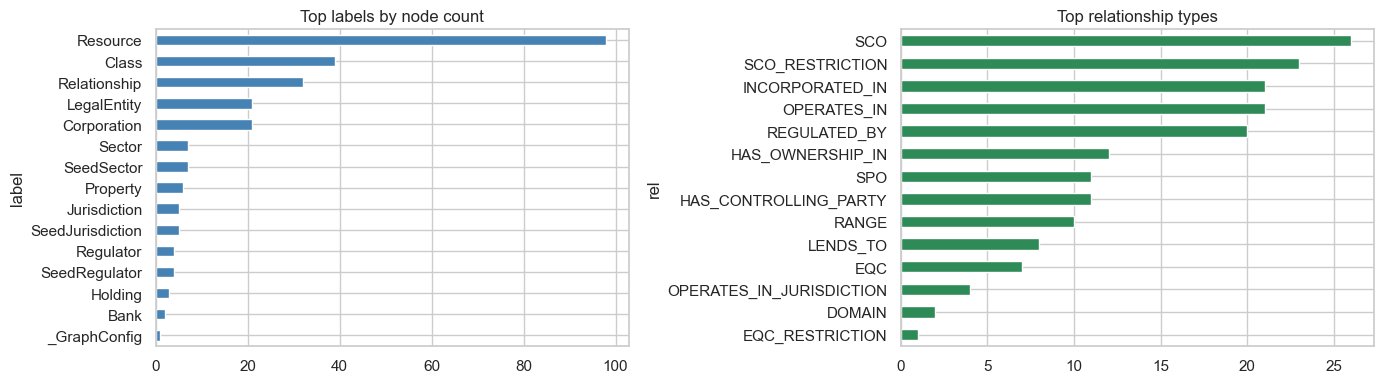

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
labels.head(15).plot.barh(x='label', y='c', ax=ax[0], color='steelblue', legend=False).invert_yaxis()
ax[0].set_title('Top labels by node count')
rels.head(15).plot.barh(x='rel', y='c', ax=ax[1], color='seagreen', legend=False).invert_yaxis()
ax[1].set_title('Top relationship types')
plt.tight_layout(); plt.show()

## 2. T-Box — FIBO class hierarchy depth

Hierarchy depth — min/median/max: 1 1.0 1


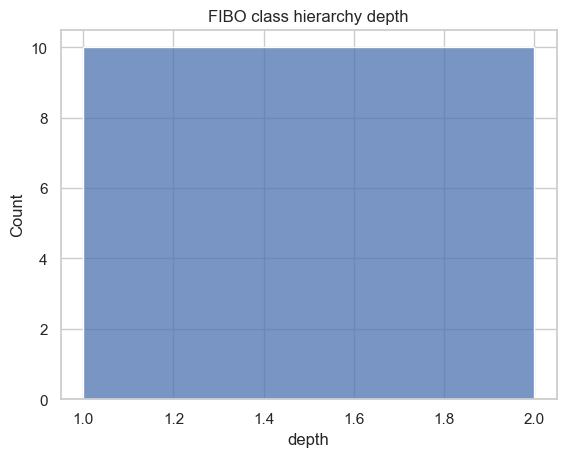

In [52]:

# Guard: only query if :Class label is present (requires 10_load_fibo.cypher)
if 'Class' in labels['label'].values:
    tbox = q("""
    MATCH path = (leaf:Class)-[:SCO*]->(root:Class)
    WHERE NOT (leaf)<-[:SCO]-(:Class) AND NOT (root)-[:SCO]->(:Class)
    RETURN length(path) AS depth
    """)
    if not tbox.empty:
        print('Hierarchy depth — min/median/max:', tbox.depth.min(), tbox.depth.median(), tbox.depth.max())
        sns.histplot(tbox.depth, bins=range(1, tbox.depth.max()+2))
        plt.title('FIBO class hierarchy depth'); plt.show()
    else:
        print('No hierarchy paths found.')
else:
    tbox = pd.DataFrame()
    print('No :Class nodes — load the FIBO ontology first (run 10_load_fibo.cypher).')


In [53]:

# Subclass tree of LegalEntity — guard against missing T-Box
if 'Class' in labels['label'].values:
    le = q("""
    MATCH path = (sub:Class)-[:SCO*1..6]->(le:Class)
    WHERE le.uri ENDS WITH 'LegalEntity'
    RETURN sub.label AS subclass, length(path) AS depth ORDER BY depth, subclass
    """)
    display(le.head(40))
else:
    le = pd.DataFrame()
    print('No :Class nodes — load the FIBO ontology first (run 10_load_fibo.cypher).')


,subclass,depth
0,[chartered legal person],1
1,"[fonds commun de placement, special purpose ve...",1
2,[statutory body],1
3,[variable interest entity],1


## 3. A-Box — counterparty network EDA

In [54]:
deg = q("""
MATCH (e:LegalEntity)
OPTIONAL MATCH (e)-[r_out]->(:LegalEntity)
OPTIONAL MATCH (e)<-[r_in]-(:LegalEntity)
RETURN e.name AS entity, e.jurisdictionCode AS country, e.sectorName AS sector,
       count(DISTINCT r_out) AS out_deg, count(DISTINCT r_in) AS in_deg
ORDER BY (count(DISTINCT r_out)+count(DISTINCT r_in)) DESC
""")
deg

,entity,country,sector,out_deg,in_deg
0,Apex Holdings Inc.,US,Holding,4,5
1,Apex Offshore Ltd,KY,Holding,3,3
2,Northwind Group Plc,UK,Holding,3,3
3,Meridian Industries Inc.,US,Energy,2,3
4,Sentinel Bank N.A.,US,Banking,4,0
5,Pacifica Trust Bank,SG,Banking,4,0
6,Apex Capital LLC,US,AssetManagement,1,2
7,Apex Energy Plc,UK,Energy,1,2
8,Apex Realty Pte Ltd,SG,RealEstate,1,2
9,Apex Insurance Ltd,UK,Insurance,2,1


In [55]:
exposure = q("""
MATCH (b:Bank)-[l:LENDS_TO]->(borrower:LegalEntity)
OPTIONAL MATCH path=(borrower)-[:HAS_CONTROLLING_PARTY*0..5]->(top)
WHERE NOT (top)-[:HAS_CONTROLLING_PARTY]->()
WITH b, top, sum(l.exposure_musd) AS exposure
RETURN b.name AS bank, coalesce(top.name,'INDEPENDENT') AS control_group, exposure
ORDER BY bank, exposure DESC
""")
exposure

,bank,control_group,exposure
0,Pacifica Trust Bank,Meridian Industries Inc.,200.0
1,Pacifica Trust Bank,Northwind Group Plc,150.0
2,Pacifica Trust Bank,Apex Holdings Inc.,120.0
3,Pacifica Trust Bank,Lotus Properties Pte Ltd,60.0
4,Sentinel Bank N.A.,Apex Holdings Inc.,430.0
5,Sentinel Bank N.A.,Meridian Industries Inc.,400.0
6,Sentinel Bank N.A.,Northwind Group Plc,90.0


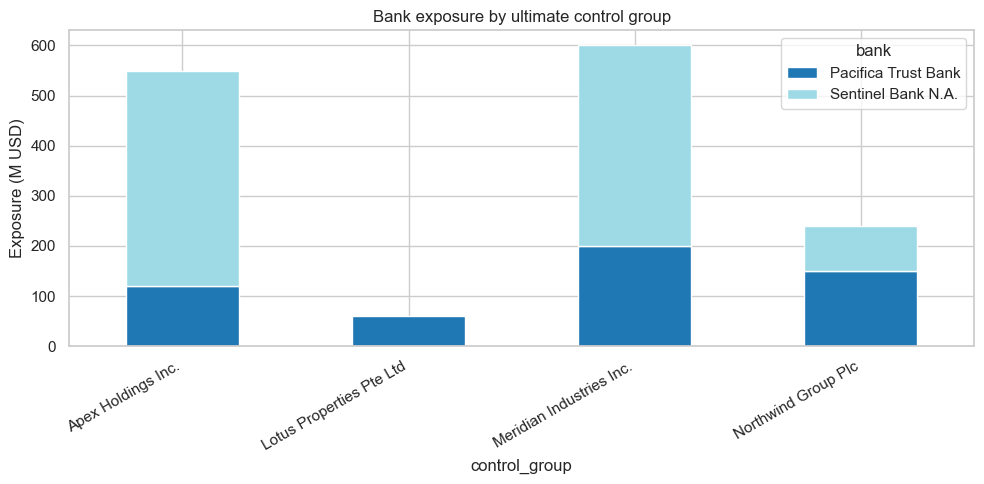

In [56]:
if not exposure.empty:
    pivot = exposure.pivot_table(index='control_group', columns='bank', values='exposure', fill_value=0)
    pivot.plot(kind='bar', stacked=True, figsize=(10,5), colormap='tab20')
    plt.ylabel('Exposure (M USD)'); plt.title('Bank exposure by ultimate control group'); plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## 4. Pull the network into NetworkX for centrality cross-checks

14 nodes / 12 edges


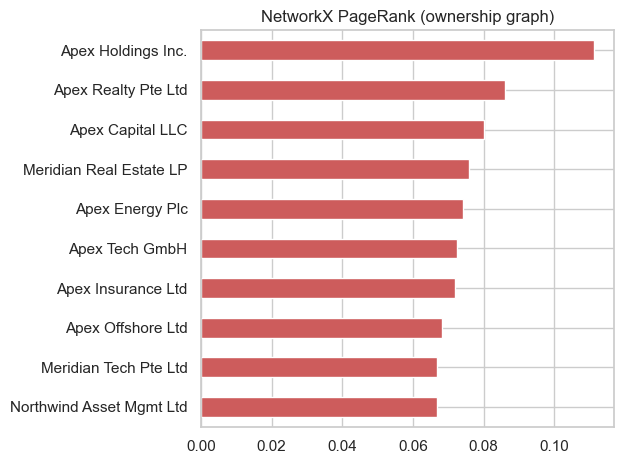

In [57]:
edges = q("""
MATCH (a:LegalEntity)-[r:HAS_OWNERSHIP_IN]->(b:LegalEntity)
RETURN a.name AS src, b.name AS dst, r.weight AS w
""")
G = nx.DiGraph()
for _, e in edges.iterrows():
    G.add_edge(e.src, e.dst, weight=float(e.w or 1.0))
print(G.number_of_nodes(), 'nodes /', G.number_of_edges(), 'edges')
pr = nx.pagerank(G, weight='weight')
pd.Series(pr).sort_values(ascending=False).head(10).plot.barh(color='indianred')
plt.gca().invert_yaxis(); plt.title('NetworkX PageRank (ownership graph)'); plt.tight_layout(); plt.show()

## 5. GDS results (must have run `40_gds_analytics.cypher` first)

In [58]:

# Only query GDS-written properties if they exist (requires 40_gds_analytics.cypher)
_prop_keys = q("CALL db.propertyKeys() YIELD propertyKey RETURN propertyKey")
_has_gds = 'systemicScore' in _prop_keys['propertyKey'].values

if _has_gds:
    gds = q("""
    MATCH (e:LegalEntity)
    RETURN e.name AS entity, e.jurisdictionCode AS country, e.sectorName AS sector,
           e.systemicScore AS pagerank, e.communityId AS community
    ORDER BY pagerank DESC
    """)
else:
    gds = q("""
    MATCH (e:LegalEntity)
    RETURN e.name AS entity, e.jurisdictionCode AS country, e.sectorName AS sector
    """)
    print('GDS properties not found — computing PageRank & WCC via NetworkX as fallback.')
    gds['pagerank'] = gds['entity'].map(pr).fillna(0.0)
    wcc_map = {node: cid
               for cid, comp in enumerate(nx.weakly_connected_components(G))
               for node in comp}
    gds['community'] = gds['entity'].map(wcc_map)
    gds = gds.sort_values('pagerank', ascending=False)
gds


,entity,country,sector,pagerank,community
0,Apex Holdings Inc.,US,Holding,0.87675,3
1,Northwind Group Plc,UK,Holding,0.53250,9
2,Apex Offshore Ltd,KY,Holding,0.40500,3
3,Meridian Industries Inc.,US,Energy,0.40500,15
4,Apex Capital LLC,US,AssetManagement,0.15000,3
5,Apex Energy Plc,UK,Energy,0.15000,3
6,Apex Tech GmbH,DE,Technology,0.15000,3
7,Apex Realty Pte Ltd,SG,RealEstate,0.15000,3
8,Apex Insurance Ltd,UK,Insurance,0.15000,3
9,Northwind Asset Mgmt Ltd,UK,AssetManagement,0.15000,9


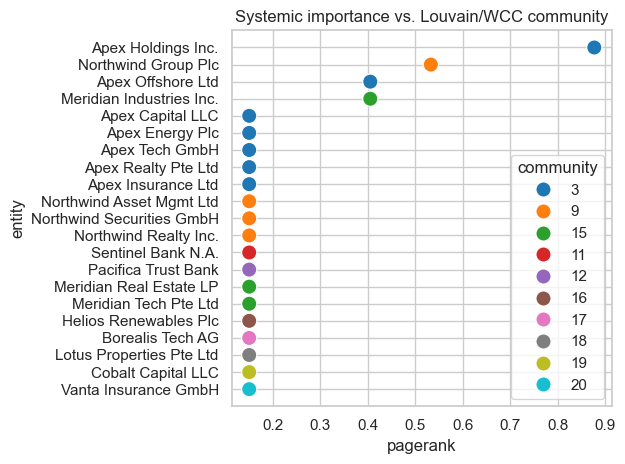

In [59]:

if 'pagerank' in gds.columns and gds['pagerank'].notna().any():
    sns.scatterplot(data=gds, x='pagerank', y='entity',
                    hue=gds['community'].astype(str), palette='tab10', s=120)
    plt.title('Systemic importance vs. Louvain/WCC community'); plt.tight_layout(); plt.show()


## 6. Default-cascade simulation (Apex Holdings)

In [60]:
cascade = q("""
MATCH (root:LegalEntity {name:'Apex Holdings Inc.'})
MATCH (root)-[:HAS_OWNERSHIP_IN*1..5]->(d)
OPTIONAL MATCH (b:Bank)-[l:LENDS_TO]->(d)
RETURN d.name AS at_risk, collect(DISTINCT b.name) AS banks, sum(l.exposure_musd) AS exposure
ORDER BY exposure DESC
""")
cascade

,at_risk,banks,exposure
0,Apex Capital LLC,[Sentinel Bank N.A.],500.0
1,Apex Energy Plc,[Sentinel Bank N.A.],360.0
2,Apex Realty Pte Ltd,[Pacifica Trust Bank],120.0
3,Apex Tech GmbH,[],0.0
4,Apex Offshore Ltd,[],0.0
5,Apex Insurance Ltd,[],0.0
6,Apex Holdings Inc.,[],0.0


## 7. Extended T-Box Analysis — Most-referenced FIBO classes & object properties

,class_label,subclasses,domain_refs,range_refs,importance_score
0,None,4,2,5,11
1,None,2,0,0,2
2,None,1,0,0,1
3,[relationship qualifier],1,0,0,1
4,[entity legal form],0,0,1,1
5,None,1,0,0,1
6,None,0,0,1,1
7,None,0,0,1,1
8,[not for profit objective],1,0,0,1
9,[business entity],0,0,0,0


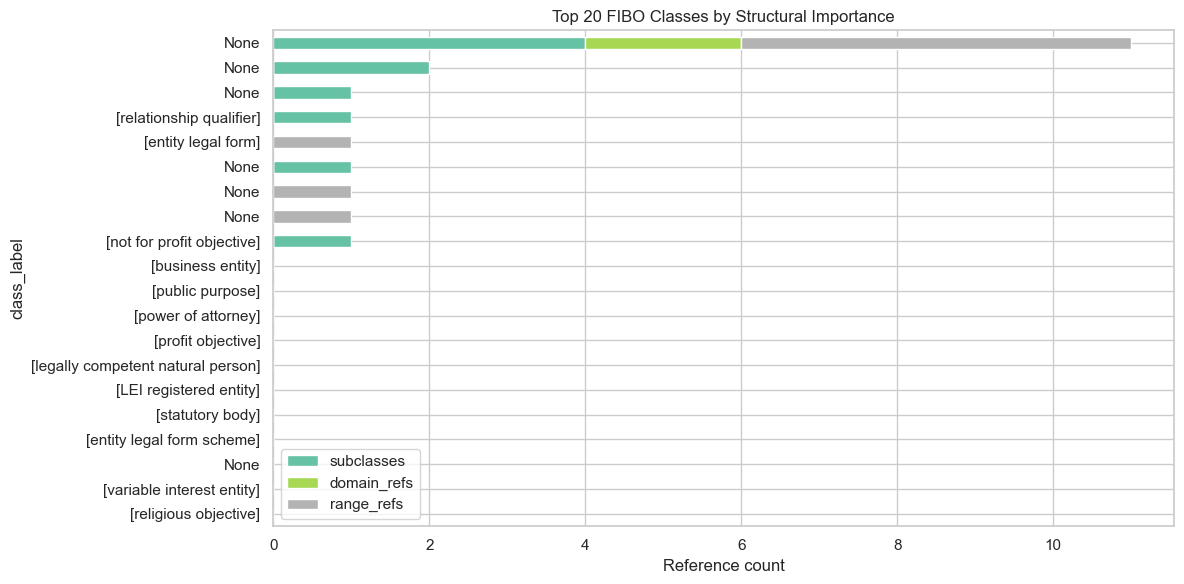

In [61]:

# Most-referenced classes (by inbound SCO + DOMAIN + RANGE relationships)
if 'Class' in labels['label'].values:
    top_classes = q("""
    MATCH (c:Class)
    OPTIONAL MATCH (c)<-[:SCO]-(sub)
    OPTIONAL MATCH (c)<-[:DOMAIN]-(d)
    OPTIONAL MATCH (c)<-[:RANGE]-(r)
    WITH c, count(DISTINCT sub) AS subclasses, count(DISTINCT d) AS domain_refs, count(DISTINCT r) AS range_refs
    RETURN c.label AS class_label, subclasses, domain_refs, range_refs,
           (subclasses + domain_refs + range_refs) AS importance_score
    ORDER BY importance_score DESC LIMIT 20
    """)
    display(top_classes)
    top_classes.plot.barh(x='class_label', y=['subclasses', 'domain_refs', 'range_refs'],
                          figsize=(12, 6), stacked=True, colormap='Set2')
    plt.gca().invert_yaxis(); plt.title('Top 20 FIBO Classes by Structural Importance')
    plt.xlabel('Reference count'); plt.tight_layout(); plt.show()
else:
    print('T-Box not loaded — skipping.')


In [62]:

# Object properties with LegalEntity in their DOMAIN (relevant for risk modelling)
if 'Class' in labels['label'].values:
    le_props = q("""
    MATCH (rel:Relationship)-[:DOMAIN]->(le:Class)
    WHERE le.uri ENDS WITH 'LegalEntity'
    OPTIONAL MATCH (rel)-[:RANGE]->(range:Class)
    RETURN rel.label AS property, range.label AS range_type, rel.uri AS uri
    ORDER BY property LIMIT 30
    """)
    if not le_props.empty:
        print(f'{len(le_props)} object properties with LegalEntity in DOMAIN:')
        display(le_props)
    else:
        print('No Relationship nodes with DOMAIN->LegalEntity found.')
else:
    print('T-Box not loaded — skipping.')


2 object properties with LegalEntity in DOMAIN:


,property,range_type,uri
0,[has legal address],None,https://spec.edmcouncil.org/fibo/ontology/BE/L...
1,[has legal form],[entity legal form],https://spec.edmcouncil.org/fibo/ontology/BE/L...


## 8. Jurisdiction & Sector Breakdown

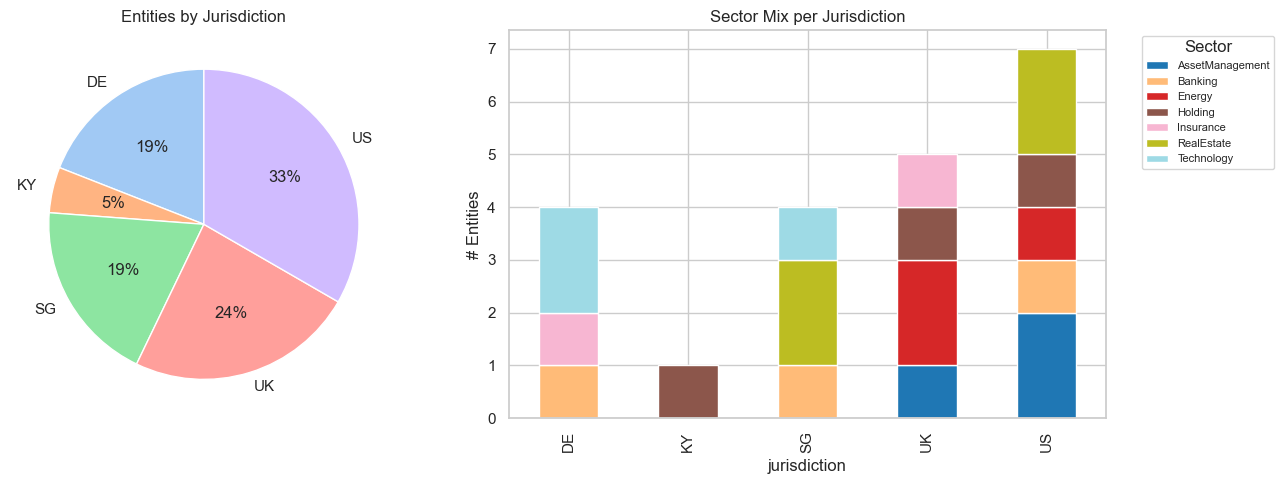

In [63]:

# Entity distribution by jurisdiction and sector
juris_sector = q("""
MATCH (e:LegalEntity)
RETURN e.jurisdictionCode AS jurisdiction, e.sectorName AS sector, count(*) AS count
ORDER BY count DESC
""")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: jurisdictions
juris_agg = juris_sector.groupby('jurisdiction')['count'].sum()
ax[0].pie(juris_agg, labels=juris_agg.index, autopct='%1.0f%%', startangle=90, colors=sns.color_palette('pastel'))
ax[0].set_title('Entities by Jurisdiction')

# Stacked bar: sector per jurisdiction
pivot_js = juris_sector.pivot_table(index='jurisdiction', columns='sector', values='count', fill_value=0)
pivot_js.plot(kind='bar', stacked=True, ax=ax[1], colormap='tab20')
ax[1].set_title('Sector Mix per Jurisdiction'); ax[1].set_ylabel('# Entities')
ax[1].legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


## 9. Ownership Concentration — Herfindahl-Hirschman Index (HHI)

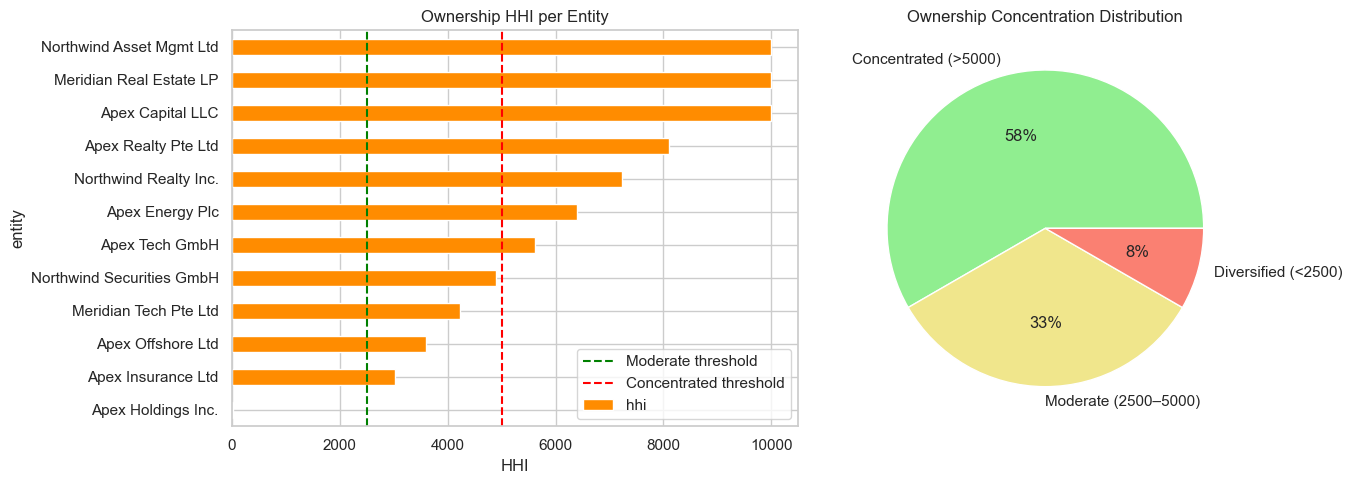

,entity,hhi,concentration
0,Apex Capital LLC,10000,Concentrated (>5000)
7,Meridian Real Estate LP,10000,Concentrated (>5000)
9,Northwind Asset Mgmt Ltd,10000,Concentrated (>5000)
5,Apex Realty Pte Ltd,8100,Concentrated (>5000)
10,Northwind Realty Inc.,7225,Concentrated (>5000)
1,Apex Energy Plc,6400,Concentrated (>5000)
6,Apex Tech GmbH,5625,Concentrated (>5000)
11,Northwind Securities GmbH,4900,Moderate (2500–5000)
8,Meridian Tech Pte Ltd,4225,Moderate (2500–5000)
4,Apex Offshore Ltd,3600,Moderate (2500–5000)


In [64]:

# Calculate HHI for each entity (how concentrated is its ownership?)
ownership = q("""
MATCH (parent:LegalEntity)-[o:HAS_OWNERSHIP_IN]->(child:LegalEntity)
RETURN child.name AS entity, parent.name AS owner, o.percent AS pct
""")

if not ownership.empty:
    # HHI = sum of squared ownership shares (normalized 0–10000)
    hhi = ownership.groupby('entity').apply(
        lambda g: (g['pct'] ** 2).sum(), include_groups=False
    ).reset_index(name='hhi')
    hhi['concentration'] = pd.cut(hhi['hhi'], bins=[0, 2500, 5000, 10001],
                                   labels=['Diversified (<2500)', 'Moderate (2500–5000)', 'Concentrated (>5000)'])

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    hhi.sort_values('hhi').plot.barh(x='entity', y='hhi', ax=ax[0], color='darkorange', legend=False)
    ax[0].axvline(2500, color='green', linestyle='--', label='Moderate threshold')
    ax[0].axvline(5000, color='red', linestyle='--', label='Concentrated threshold')
    ax[0].legend(); ax[0].set_title('Ownership HHI per Entity'); ax[0].set_xlabel('HHI')

    hhi['concentration'].value_counts().plot.pie(ax=ax[1], autopct='%1.0f%%',
                                                  colors=['lightgreen', 'khaki', 'salmon'])
    ax[1].set_ylabel(''); ax[1].set_title('Ownership Concentration Distribution')
    plt.tight_layout(); plt.show()
    display(hhi.sort_values('hhi', ascending=False))
else:
    print('No ownership data found.')


## 10. Circular Ownership Detection (Red Flags)

In [65]:

# Detect cycles in the ownership graph (regulatory red flag)
cycles = list(nx.simple_cycles(G))
if cycles:
    print(f'⚠️  {len(cycles)} circular ownership cycle(s) detected:\n')
    for i, cycle in enumerate(cycles, 1):
        chain = ' → '.join(cycle + [cycle[0]])
        print(f'  Cycle {i}: {chain}')
        # Show the ownership %s in the cycle
        for j in range(len(cycle)):
            src, dst = cycle[j], cycle[(j+1) % len(cycle)]
            edge_data = G.edges[src, dst]
            print(f'    {src} --[{edge_data["weight"]*100:.0f}%]--> {dst}')
        print()
else:
    print('✓ No circular ownership detected.')


⚠️  1 circular ownership cycle(s) detected:

  Cycle 1: Apex Holdings Inc. → Apex Offshore Ltd → Apex Insurance Ltd → Apex Holdings Inc.
    Apex Holdings Inc. --[60%]--> Apex Offshore Ltd
    Apex Offshore Ltd --[55%]--> Apex Insurance Ltd
    Apex Insurance Ltd --[5%]--> Apex Holdings Inc.



## 11. Risk Concentration — Bank Exposure Heatmap

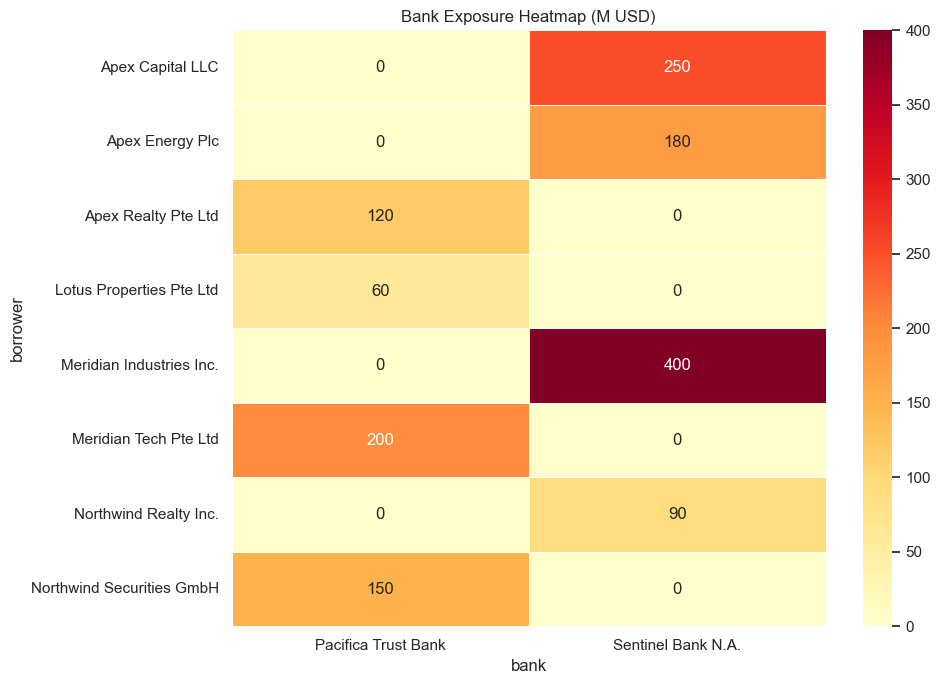

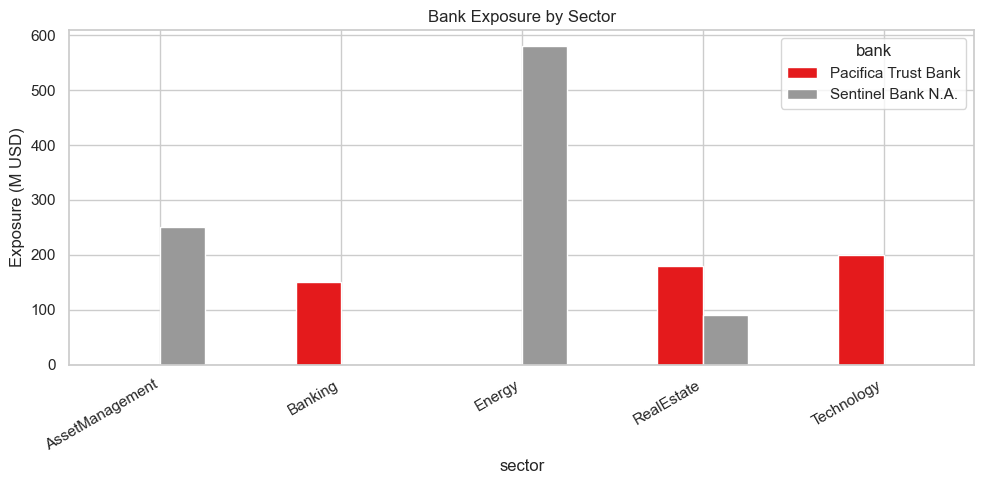

In [66]:

# Detailed bank exposure by borrower — heatmap
bank_loans = q("""
MATCH (b:Bank)-[l:LENDS_TO]->(e:LegalEntity)
RETURN b.name AS bank, e.name AS borrower, e.sectorName AS sector,
       e.jurisdictionCode AS jurisdiction, l.exposure_musd AS exposure
ORDER BY exposure DESC
""")

if not bank_loans.empty:
    heatmap_data = bank_loans.pivot_table(index='borrower', columns='bank', values='exposure', fill_value=0)
    plt.figure(figsize=(10, 7))
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Bank Exposure Heatmap (M USD)'); plt.tight_layout(); plt.show()

    # Exposure by sector
    sector_exp = bank_loans.groupby(['bank', 'sector'])['exposure'].sum().reset_index()
    fig, ax = plt.subplots(figsize=(10, 5))
    sector_pivot = sector_exp.pivot_table(index='sector', columns='bank', values='exposure', fill_value=0)
    sector_pivot.plot(kind='bar', ax=ax, colormap='Set1')
    ax.set_title('Bank Exposure by Sector'); ax.set_ylabel('Exposure (M USD)')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
else:
    print('No lending data found.')


## 12. Network Topology Summary & Betweenness Centrality

=== Ownership Network Topology ===
  Nodes: 14
  Edges: 12
  Density: 0.0659
  Weakly Connected Components: 3
  Strongly Connected Components: 12
  Contains cycles: True


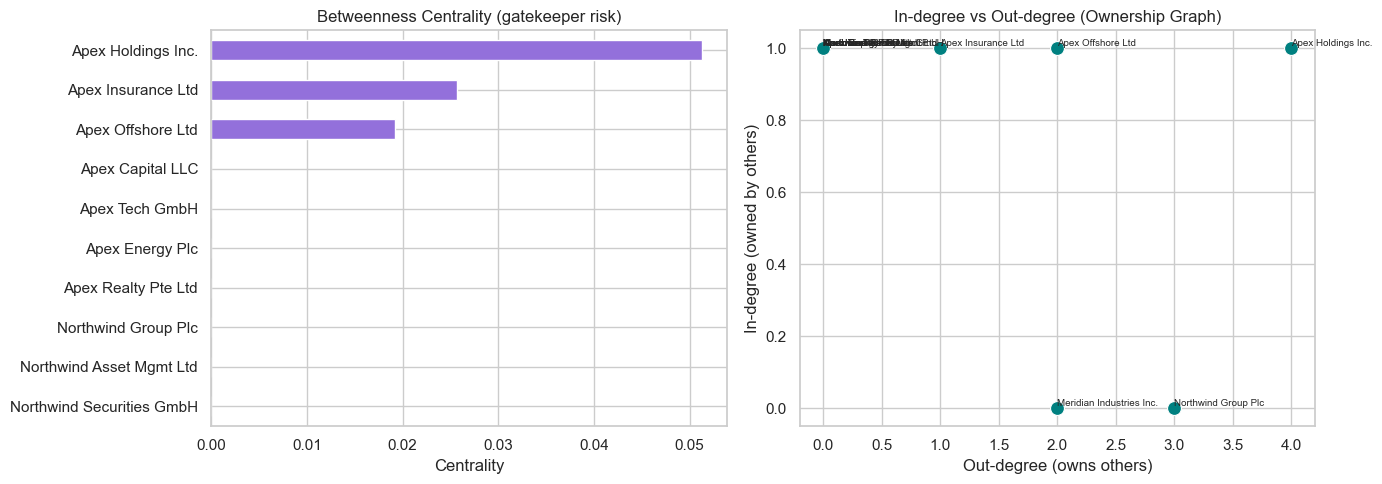

In [67]:

# Network topology metrics
print('=== Ownership Network Topology ===')
print(f'  Nodes: {G.number_of_nodes()}')
print(f'  Edges: {G.number_of_edges()}')
print(f'  Density: {nx.density(G):.4f}')
print(f'  Weakly Connected Components: {nx.number_weakly_connected_components(G)}')
print(f'  Strongly Connected Components: {nx.number_strongly_connected_components(G)}')
dag = not nx.is_directed_acyclic_graph(G)
print(f'  Contains cycles: {dag}')

# Betweenness centrality (identifies bottleneck/gatekeeper entities)
betw = nx.betweenness_centrality(G, weight='weight')
betw_df = pd.Series(betw).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Betweenness
betw_df.plot.barh(ax=ax[0], color='mediumpurple')
ax[0].invert_yaxis(); ax[0].set_title('Betweenness Centrality (gatekeeper risk)')
ax[0].set_xlabel('Centrality')

# In-degree vs Out-degree scatter
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
deg_df = pd.DataFrame({'entity': list(G.nodes()),
                       'in_degree': [in_deg[n] for n in G.nodes()],
                       'out_degree': [out_deg[n] for n in G.nodes()]})
sns.scatterplot(data=deg_df, x='out_degree', y='in_degree', ax=ax[1], s=100, color='teal')
for _, row in deg_df.iterrows():
    ax[1].annotate(row['entity'], (row['out_degree'], row['in_degree']),
                   fontsize=7, ha='left', va='bottom')
ax[1].set_title('In-degree vs Out-degree (Ownership Graph)')
ax[1].set_xlabel('Out-degree (owns others)'); ax[1].set_ylabel('In-degree (owned by others)')
plt.tight_layout(); plt.show()


## 13. Ultimate Beneficial Ownership (UBO) Chain Analysis

,entity,country,ultimate_controller,control_chain_length
0,Apex Insurance Ltd,UK,Apex Holdings Inc.,2
1,Apex Realty Pte Ltd,SG,Apex Holdings Inc.,2
2,Apex Capital LLC,US,Apex Holdings Inc.,1
3,Apex Energy Plc,UK,Apex Holdings Inc.,1
4,Apex Offshore Ltd,KY,Apex Holdings Inc.,1
5,Apex Tech GmbH,DE,Apex Holdings Inc.,1
6,Meridian Real Estate LP,US,Meridian Industries Inc.,1
7,Meridian Tech Pte Ltd,SG,Meridian Industries Inc.,1
8,Northwind Asset Mgmt Ltd,UK,Northwind Group Plc,1
9,Northwind Realty Inc.,US,Northwind Group Plc,1


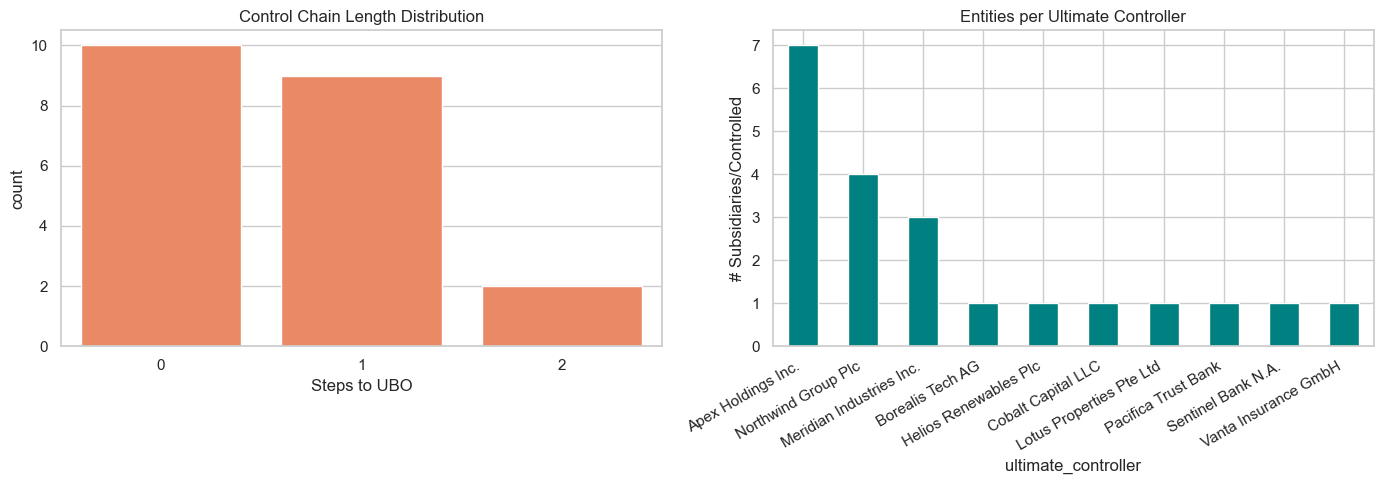

In [68]:

# Trace each entity back to its ultimate controlling party (UBO)
ubo = q("""
MATCH (e:LegalEntity)
OPTIONAL MATCH path = (e)-[:HAS_CONTROLLING_PARTY*1..10]->(ubo:LegalEntity)
WHERE NOT (ubo)-[:HAS_CONTROLLING_PARTY]->()
WITH e, ubo, length(path) AS chain_depth
RETURN e.name AS entity, e.jurisdictionCode AS country,
       coalesce(ubo.name, e.name) AS ultimate_controller,
       coalesce(chain_depth, 0) AS control_chain_length
ORDER BY control_chain_length DESC, entity
""")
display(ubo)

# Visualize chain length distribution
if ubo['control_chain_length'].max() > 0:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(data=ubo, x='control_chain_length', ax=ax[0], color='coral')
    ax[0].set_title('Control Chain Length Distribution')
    ax[0].set_xlabel('Steps to UBO')

    # Group by UBO
    ubo_groups = ubo.groupby('ultimate_controller').size().sort_values(ascending=False)
    ubo_groups.plot.bar(ax=ax[1], color='teal')
    ax[1].set_title('Entities per Ultimate Controller')
    ax[1].set_ylabel('# Subsidiaries/Controlled')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


## 14. Cross-Jurisdiction Risk & Regulatory Exposure Summary

Cross-jurisdiction ownership flows:


,from_jurisdiction,to_jurisdiction,links,avg_ownership_pct
0,UK,US,2,45.0
1,US,UK,1,80.0
2,US,DE,1,75.0
3,US,KY,1,60.0
4,KY,SG,1,90.0
5,KY,UK,1,55.0
6,UK,DE,1,70.0
7,US,SG,1,65.0



Regulatory oversight summary:


,regulator,entities,ownership_links
0,SEC,7,6
1,FCA,5,4
2,BaFin,4,0
3,MAS,4,0


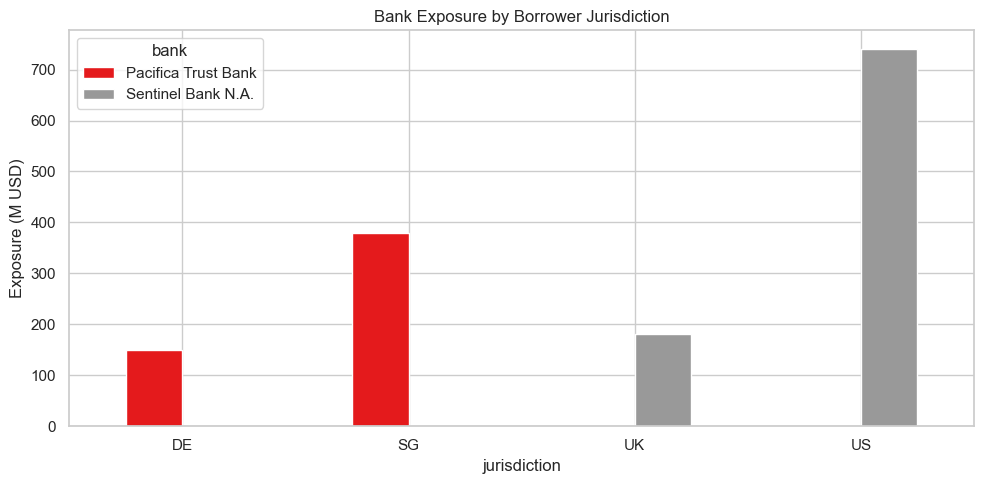

In [69]:

# Cross-jurisdiction ownership flows
cross_juris = q("""
MATCH (parent:LegalEntity)-[o:HAS_OWNERSHIP_IN]->(child:LegalEntity)
WHERE parent.jurisdictionCode <> child.jurisdictionCode
RETURN parent.jurisdictionCode AS from_jurisdiction,
       child.jurisdictionCode AS to_jurisdiction,
       count(*) AS links, avg(o.percent) AS avg_ownership_pct
ORDER BY links DESC
""")
print('Cross-jurisdiction ownership flows:')
display(cross_juris)

# Regulatory exposure: which regulators oversee the most inter-connected entities?
reg_exposure = q("""
MATCH (e:LegalEntity)-[:REGULATED_BY]->(reg:Regulator)
OPTIONAL MATCH (e)-[o:HAS_OWNERSHIP_IN]->()
WITH reg, count(DISTINCT e) AS entities, count(o) AS ownership_links
RETURN reg.name AS regulator, entities, ownership_links
ORDER BY entities DESC
""")
print('\nRegulatory oversight summary:')
display(reg_exposure)

# Bank exposure by jurisdiction
if not bank_loans.empty:
    juris_exp = bank_loans.groupby(['bank', 'jurisdiction'])['exposure'].sum().reset_index()
    juris_pivot = juris_exp.pivot_table(index='jurisdiction', columns='bank', values='exposure', fill_value=0)
    juris_pivot.plot(kind='bar', figsize=(10, 5), colormap='Set1')
    plt.title('Bank Exposure by Borrower Jurisdiction')
    plt.ylabel('Exposure (M USD)'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


In [ ]:
driver.close()

: 